In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict

In [87]:
root_path = '/Users/mariana/Documents/projects/Huawei/Results/'
task_id = 'big_rw'
# sa_is_path = os.path.join(root_path, f"SA/single_task/transformer/lambda_0.9/landmark_False/taskid_{task_id}")
# sa_lm_path = os.path.join(root_path, f"SA/single_task/transformer/lambda_0.9/landmark_True/taskid_{task_id}")
# dl_00_path = os.path.join(root_path, f"DeepLambdaSA/single_task/transformer/lambda_0.0/landmark_True/taskid_{task_id}")
# # dl_01_path = os.path.join(root_path, "DeepLambdaSA/single_task/lambda_0.1/landmark_True/")
# dl_09_path = os.path.join(root_path, f"DeepLambdaSA/single_task/transformer/lambda_0.9/landmark_True/taskid_{task_id}")

# paths = [sa_is_path, sa_lm_path, dl_00_path, dl_09_path]

In [119]:
# sa_is_path = os.path.join(root_path, f"SA/churn_lastfm_months/lambda_0.9/landmark_False/")
# sa_lm_path = os.path.join(root_path, f"SA/churn_lastfm_months/lambda_0.9/landmark_True/")
# dl_00_path = os.path.join(root_path, f"DeepLambdaSA/churn_lastfm_months/lambda_0.0/landmark_True/")
# dl_09_path = os.path.join(root_path, f"DeepLambdaSA/churn_lastfm_months/lambda_0.9/landmark_True/")

sa_is_path = os.path.join(root_path, f"SA/{task_id}/transformer/lambda_0.0/landmark_False/")
sa_lm_path = os.path.join(root_path, f"SA/{task_id}/transformer/lambda_0.0/landmark_True/")
dl_00_path = os.path.join(root_path, f"DeepLambdaSA/{task_id}/transformer/lambda_0.0/landmark_True/")
dl_09_path = os.path.join(root_path, f"DeepLambdaSA/{task_id}/transformer/lambda_0.9/landmark_True/")

paths = [sa_is_path, sa_lm_path, dl_00_path, dl_09_path]

In [120]:
paths

['/Users/mariana/Documents/projects/Huawei/Results/SA/big_rw/transformer/lambda_0.0/landmark_False/',
 '/Users/mariana/Documents/projects/Huawei/Results/SA/big_rw/transformer/lambda_0.0/landmark_True/',
 '/Users/mariana/Documents/projects/Huawei/Results/DeepLambdaSA/big_rw/transformer/lambda_0.0/landmark_True/',
 '/Users/mariana/Documents/projects/Huawei/Results/DeepLambdaSA/big_rw/transformer/lambda_0.9/landmark_True/']

In [121]:
# Function to process a result.json file
def process_result_file(file_path):
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)
        if 'ci' in data:
            ci = data['ci']
        if 'bs' in data:
            bs = data['bs']
    return ci, bs

In [126]:
res = defaultdict(dict)

# Iterate through all subdirectories and files
cis_, bss_ = [], []
for path in paths:
    cis, bss = [], []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file == 'results.json':
                file_path = os.path.join(root, file)
                ci, bs = process_result_file(file_path)
                cis.append(ci)
                bss.append(bs)
    cis = np.array(cis)
    bss = np.array(bss)
    cis_.append(cis)
    bss_.append(bss)
    # res[path] = {'ci_mu': cis.mean(), 'ci_std': cis.std(), 'bs_mu': bss.mean(),
    #              'bs_std': bss.std()}
    res[path] = {'ci_mu': cis,
                 'bs_std': bss}

In [127]:
cis

array([0.91071433, 0.7319843 , 0.73051816, 0.87322551, 0.88729997])

In [128]:
res

defaultdict(dict,
            {'/Users/mariana/Documents/projects/Huawei/Results/SA/big_rw/transformer/lambda_0.0/landmark_False/': {'ci_mu': array([0.58838566, 0.63725986, 0.8928306 , 0.85691862, 0.71704169]),
              'bs_std': array([0.53136939, 0.43316466, 0.17541321, 0.1589793 , 0.29325834])},
             '/Users/mariana/Documents/projects/Huawei/Results/SA/big_rw/transformer/lambda_0.0/landmark_True/': {'ci_mu': array([0.82193402, 0.68237665, 0.69158414, 0.66723341, 0.69984343]),
              'bs_std': array([0.09986591, 0.19595858, 0.19812053, 0.18410638, 0.17711036])},
             '/Users/mariana/Documents/projects/Huawei/Results/DeepLambdaSA/big_rw/transformer/lambda_0.0/landmark_True/': {'ci_mu': array([0.58109949, 0.90302428, 0.5       , 0.5889813 , 0.9171554 ,
                     0.72197091]),
              'bs_std': array([0.50847799, 0.15037677, 0.52682322, 0.49399388, 0.15087447,
                     0.19743693])},
             '/Users/mariana/Documents/projects

In [114]:
bss_fm = bss_
cis_fm = cis_

In [115]:
bss_rw = bss_
cis_rw = cis_

In [116]:
cis_rw

[array([0.58838566, 0.63725986, 0.8928306 , 0.85691862, 0.71704169]),
 array([0.82193402, 0.68237665, 0.69158414, 0.66723341, 0.69984343]),
 array([0.92365217, 0.7433215 , 0.73327772, 0.58339097, 0.73180187]),
 array([0.91071433, 0.7319843 , 0.73051816, 0.87322551, 0.88729997])]

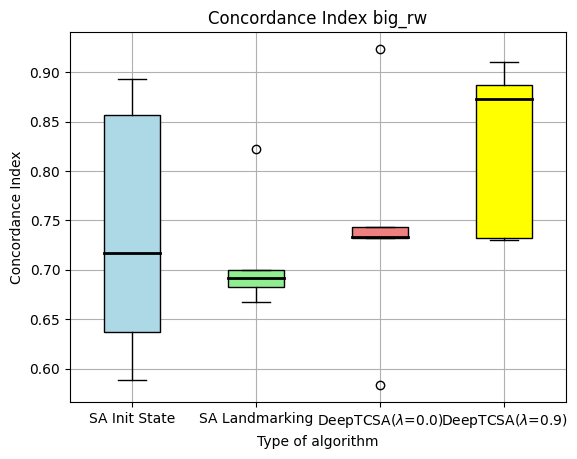

In [117]:
savefig= False
# task_id = 11

# Create a figure and axis
fig, ax = plt.subplots()


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
boxplot = ax.boxplot(cis_,
                     medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['SA Init State', 'SA Landmarking', r'DeepTCSA($\lambda$=0.0)', r'DeepTCSA($\lambda$=0.9)'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Concordance Index")
ax.set_title("Concordance Index {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if savefig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/{}/Concordance_idx.pdf".format(task_id), format="pdf")

plt.show()


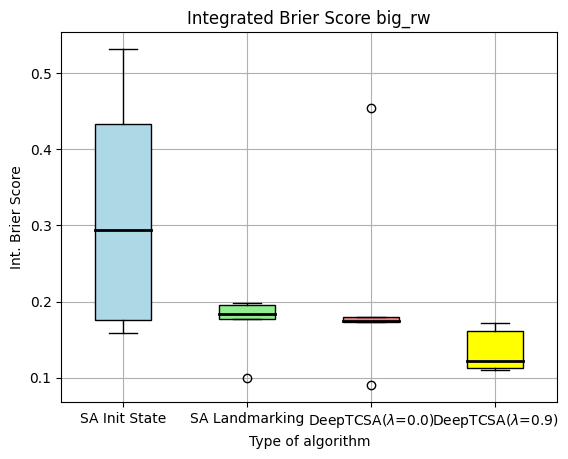

In [118]:



# Create a figure and axis
fig, ax = plt.subplots()


# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

# Create the boxplots
boxplot = ax.boxplot(bss_, medianprops=medianprops, positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['SA Init State', 'SA Landmarking', r'DeepTCSA($\lambda$=0.0)', r'DeepTCSA($\lambda$=0.9)'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score {}".format(task_id))
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'yellow']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
if savefig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/{}/Int_brier_score.pdf".format(task_id), format="pdf")

plt.show()


In [135]:
# Iterate over task ids

In [150]:
root_path = '/Users/mariana/Documents/projects/Huawei/Results/'
task_ids = [4, 5, 6,10, 11]

all_res = []

for task_id in task_ids:
    sa_is_path = os.path.join(root_path, f"SA/single_task/transformer/lambda_0.9/landmark_False/taskid_{task_id}")
    sa_lm_path = os.path.join(root_path, f"SA/single_task/transformer/lambda_0.9/landmark_True/taskid_{task_id}")
    dl_00_path = os.path.join(root_path, f"DeepLambdaSA/single_task/transformer/lambda_0.0/landmark_True/taskid_{task_id}")
    dl_09_path = os.path.join(root_path, f"DeepLambdaSA/single_task/transformer/lambda_0.9/landmark_True/taskid_{task_id}")
    
    paths = [sa_is_path, sa_lm_path, dl_00_path, dl_09_path]

    # Iterate through all subdirectories and files
    res = defaultdict(dict)
    for path in paths:
        cis, bss = [], []
        for root, dirs, files in os.walk(path):
            for file in files:
                if file == 'results.json':
                    file_path = os.path.join(root, file)
                    ci, bs = process_result_file(file_path)
                    cis.append(ci)
                    bss.append(bs)
        cis = np.array(cis)
        bss = np.array(bss)

        res[path] = {'cis': cis,
                          'bss': bss}
    all_res.append(res)

In [141]:
task_ids

[4, 5, 6, 10, 11]

In [149]:
all_res[2]

defaultdict(dict,
            {'/Users/mariana/Documents/projects/Huawei/Results/SA/single_task/transformer/lambda_0.9/landmark_False/taskid_6': {'ci_mu': array([0.94784795, 0.94589705, 0.93846348, 0.93965442, 0.91353762]),
              'ci_std': array([0.94784795, 0.94589705, 0.93846348, 0.93965442, 0.91353762]),
              'bs_mu': array([0.07178937, 0.07964262, 0.04787637, 0.04263867, 0.04196348]),
              'bs_std': array([0.07178937, 0.07964262, 0.04787637, 0.04263867, 0.04196348])},
             '/Users/mariana/Documents/projects/Huawei/Results/SA/single_task/transformer/lambda_0.9/landmark_True/taskid_6': {'ci_mu': array([0.94673764, 0.97796778, 0.93058226, 0.92564615, 0.94564799]),
              'ci_std': array([0.94673764, 0.97796778, 0.93058226, 0.92564615, 0.94564799]),
              'bs_mu': array([0.00811926, 0.00984857, 0.00750748, 0.05175643, 0.01081023]),
              'bs_std': array([0.00811926, 0.00984857, 0.00750748, 0.05175643, 0.01081023])},
             

In [146]:
d = defaultdict(dict)

In [ ]:
for task_id, res in zip(task_ids, all_res):
    for key, value in res:
        
    d[task_id]

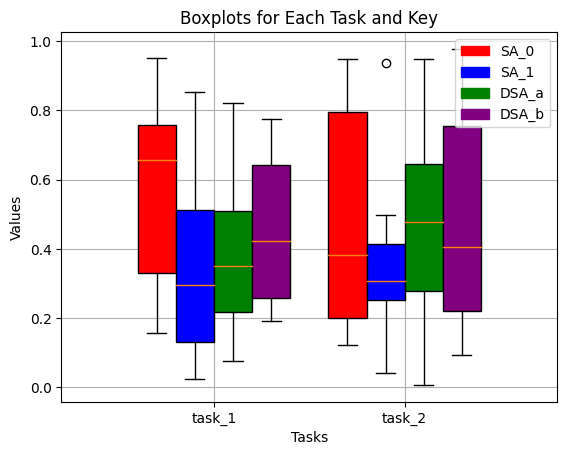

In [28]:
d = {
    'task_1': {'SA_0': np.random.rand(10), 'SA_1': np.random.rand(10),
               'DSA_a': np.random.rand(10), 'DSA_b': np.random.rand(10)},
    'task_2': {'SA_0': np.random.rand(10), 'SA_1': np.random.rand(10),
               'DSA_a': np.random.rand(10), 'DSA_b': np.random.rand(10)}
}

# Define colors for each key
colors = {'SA_0': 'red', 'SA_1': 'blue', 'DSA_a': 'green', 'DSA_b': 'purple'}

# Prepare data for plotting
tasks = list(d.keys())
keys = list(d[tasks[0]].keys())

fig, ax = plt.subplots()

# Create boxplots
for i, key in enumerate(keys):
    data = [d[task][key] for task in tasks]
    box = ax.boxplot(data, positions=np.arange(len(tasks)) + i * 0.2,
                     widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))

# Create legend
legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
ax.legend(legend_labels, keys, loc='upper right')

# Set labels and title
ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
ax.set_xticklabels(tasks)
ax.set_xlabel('Tasks')
ax.set_ylabel('Values')
ax.set_title('Boxplots for Each Task and Key')

plt.grid()
plt.show()

In [29]:
data

[array([0.71292981, 0.20270012, 0.23067133, 0.65137414, 0.61136844,
        0.77656782, 0.33527442, 0.48376288, 0.36163287, 0.19164439]),
 array([0.21247343, 0.7739524 , 0.34147479, 0.97801514, 0.88922244,
        0.24214676, 0.21455124, 0.46830212, 0.69707732, 0.09472976])]

In [30]:
keys

['SA_0', 'SA_1', 'DSA_a', 'DSA_b']

In [63]:
cis_fm

[array([0.58838566, 0.63725986, 0.8928306 , 0.85691862, 0.71704169]),
 array([0.82193402, 0.68237665, 0.69158414, 0.66723341, 0.69984343]),
 array([0.89620563, 0.73025498, 0.91765753, 0.74905176, 0.90744638]),
 array([0.91071433, 0.7319843 , 0.73051816, 0.68906136, 0.71712621])]

In [41]:
all_res = [
    (cis_fm, ''),
    cis_rw,
    bss_fm,
    bss_rw
]

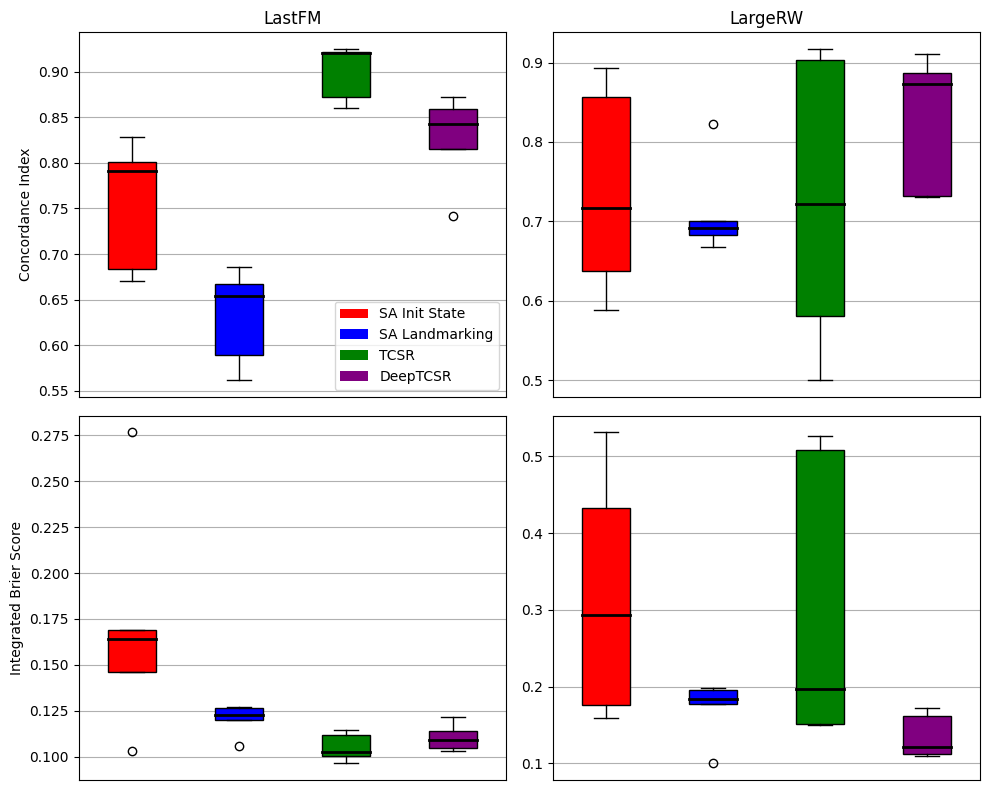

In [86]:
save_fig = True

# Define colors for each key
d_colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSR': 'green', 'DeepTCSR': 'purple'}
labels, colors = zip(*d_colors.items())
colors = list(colors)
labels = list(labels)

# Compiling all results
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

# Set the positions for the boxes
positions = [1, 2, 3, 4]

medianprops = dict(color='black', linewidth=2)

for i, ax in enumerate(axs):

    data = all_res[i]
    
    # Create the boxplots
    boxplot = ax.boxplot(data,
                         medianprops=medianprops, positions=positions,
                         patch_artist=True,
                         labels=labels)
    # Assign colors to each box
    for box, color in zip(boxplot['boxes'], colors):
        box.set_facecolor(color)

    # Customize the appearance (colors, labels, etc.) as needed
    # ax.set_xticks(positions)
    ax.set_xticks([]) 

    # if i == 2 or i == 3:
    # ax.set_xticklabels(['SA Init State', 'SA Landmarking', r'DeepTCSA($\lambda$=0.0)', r'DeepTCSA($\lambda$=0.9)'])
        
    # ax.set_xlabel("Type of algorithm")
    if i == 0:
        ax.set_ylabel("Concordance Index")
        ax.set_title(f'LastFM')
        legend_labels = [f'{label}' for label in labels]
        legend = ax.legend(boxplot['boxes'], legend_labels, loc='lower right')
        # Remove black frame around legend markers
        for handle in legend.legend_handles:
            handle.set_edgecolor('None')

    if i == 1:
        ax.set_title(f'LargeRW')

    if i == 2:
        ax.set_ylabel("Integrated Brier Score")
        
    ax.grid()

if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/LargelDS_results.pdf", format="pdf")


plt.show()
